In [1]:
# VISIOASSIST YOLOv8s

In [2]:
import torch
print(torch.cuda.is_available())

True


In [3]:
!pip install ultralytics roboflow -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.5/169.5 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 68.3 MB/s eta 0:00:00


In [4]:
# Descargar dataset desde roboflow
import os
from roboflow import Roboflow

rf = Roboflow(api_key="x1eRfpyAJCkbCSCXShwV")
project = rf.workspace("miltons-workspace-koggn").project("visioassist-sucre")
version = project.version(1)
dataset = version.download("yolov8")

DATA_YAML = os.path.join(dataset.location, "data.yaml")
print(f"dataset en : {dataset.location}")
print(f"data.yaml  : {DATA_YAML}")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to VisioAssist-Sucre-1 in yolov8:: 100%|██████████| 1419/1419 [00:00<00:00, 1622.30it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
dataset en : /content/VisioAssist-Sucre-1
data.yaml  : /content/VisioAssist-Sucre-1/data.yaml


In [9]:
# Entrenamiento
from ultralytics import YOLO

model = YOLO("yolov8s.pt")

model.train(
    data = DATA_YAML,
    epochs = 100,
    batch = 8,  # YOLOv8s ocupa mas VRAM
    imgsz = 640,
    patience = 20,
    optimizer = "AdamW",
    lr0 = 0.001,
    lrf = 0.01,
    weight_decay = 0.0005,
    hsv_v = 0.4,
    scale = 0.7, # variacion de escala para distintas distancias
    fliplr = 0.5,
    mosaic = 1.0,
    copy_paste = 0.2, # ayuda a branch y awning
    project = "VisioAssist",
    name = "yolov8s_v1",
    exist_ok = True,
    device = 0,
    workers = 2,
    verbose = True,
)

BEST_MODEL = "VisioAssist/yolov8s_v1/weights/best.pt"

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.2, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/VisioAssist-Sucre-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8s_v1, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, p

In [10]:
# Evaluacion en conjunto test
BEST_MODEL = "/content/runs/detect/VisioAssist/yolov8s_v1/weights/best.pt"

best = YOLO(BEST_MODEL)
metrics = best.val(data=DATA_YAML, split="test", imgsz=640, device=0)

print("Resultados")
print(f"mAP50: {metrics.box.map50 * 100:.2f}%")
print(f"mAP50-95: {metrics.box.map   * 100:.2f}%")
print(f"precision: {metrics.box.mp    * 100:.2f}%")
print(f"recall: {metrics.box.mr    * 100:.2f}%")

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,127,906 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2178.3±492.5 MB/s, size: 71.7 KB)
val: Scanning /content/VisioAssist-Sucre-1/test/labels.cache... 71 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 71/71 33.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 1.7it/s 2.9s
                   all         71        124      0.855      0.774      0.833       0.56
                awning         10         13      0.818      0.846      0.886      0.574
                branch          4          4      0.646        0.5      0.487      0.203
                person         21         28      0.921      0.836      0.944      0.657
                  pole         31         33      0.929      0.848      0.912       0.74
                  sign         21        

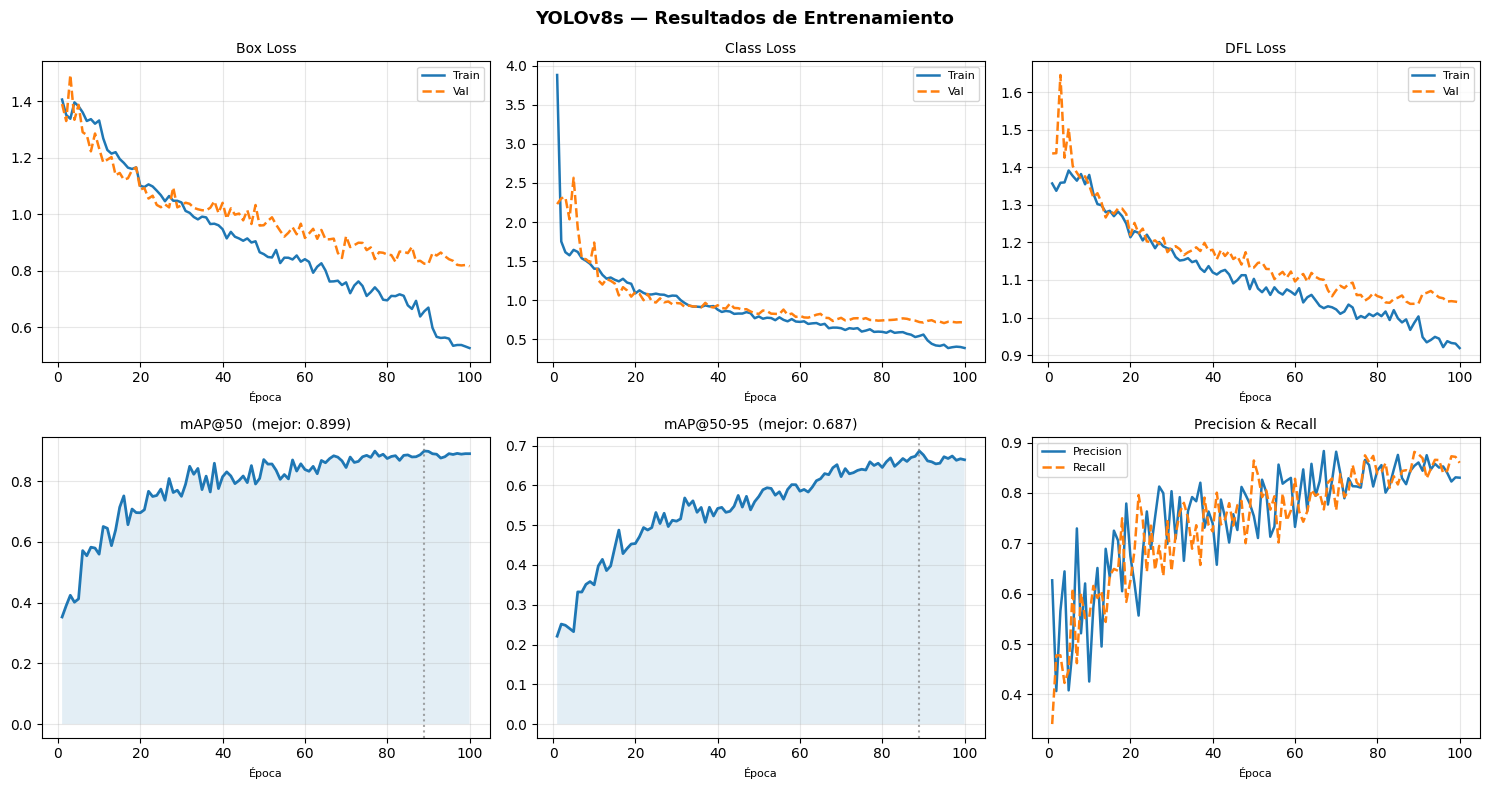

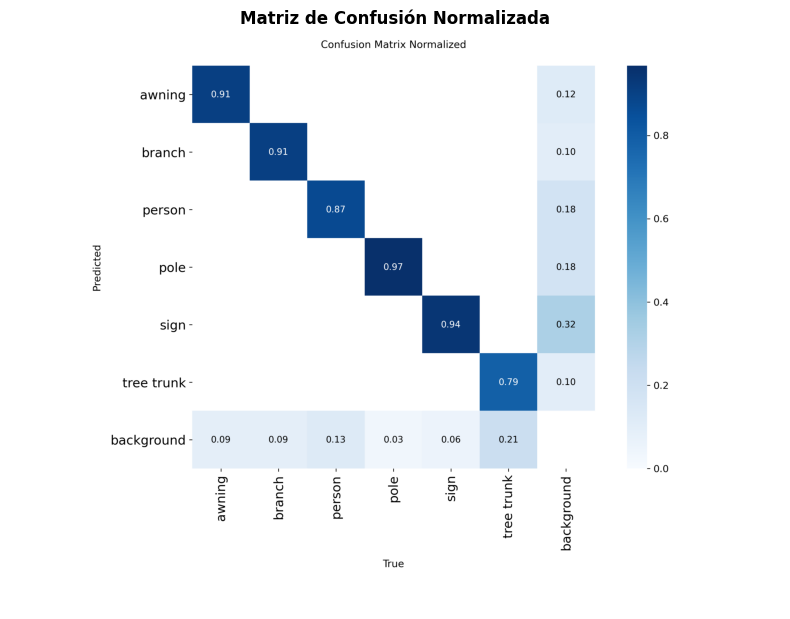

In [11]:
# Graficas de entrenamiento
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

df = pd.read_csv("/content/runs/detect/VisioAssist/yolov8s_v1/results.csv")
df.columns = df.columns.str.strip()
ep = df["epoch"].values

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("YOLOv8s — Resultados de Entrenamiento", fontsize=13, fontweight="bold")

def linea(ax, y_train, y_val, title):
    ax.plot(ep, y_train, label="Train", linewidth=1.8)
    ax.plot(ep, y_val, label="Val", linewidth=1.8, linestyle="--")
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Época", fontsize=8)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

def curva(ax, y, title):
    ax.plot(ep, y, linewidth=2)
    ax.fill_between(ep, y, alpha=0.12)
    best_val = y.max()
    best_ep = ep[y.argmax()]
    ax.axvline(best_ep, color="gray", linestyle=":", alpha=0.7)
    ax.set_title(f"{title}  (mejor: {best_val:.3f})", fontsize=10)
    ax.set_xlabel("Época", fontsize=8)
    ax.grid(alpha=0.3)

linea(axes[0, 0], df["train/box_loss"], df["val/box_loss"], "Box Loss")
linea(axes[0, 1], df["train/cls_loss"], df["val/cls_loss"], "Class Loss")
linea(axes[0, 2], df["train/dfl_loss"], df["val/dfl_loss"], "DFL Loss")

curva(axes[1, 0], df["metrics/mAP50(B)"], "mAP@50")
curva(axes[1, 1], df["metrics/mAP50-95(B)"], "mAP@50-95")

axes[1, 2].plot(ep, df["metrics/precision(B)"], label="Precision", linewidth=1.8)
axes[1, 2].plot(ep, df["metrics/recall(B)"], label="Recall", linewidth=1.8, linestyle="--")
axes[1, 2].set_title("Precision & Recall", fontsize=10)
axes[1, 2].set_xlabel("Época", fontsize=8)
axes[1, 2].legend(fontsize=8)
axes[1, 2].grid(alpha=0.3)

# matriz de confusion
plt.tight_layout()
plt.savefig("yolov8s_resultados.png", dpi=130, bbox_inches="tight")
plt.show()

img = Image.open("/content/runs/detect/VisioAssist/yolov8s_v1/confusion_matrix_normalized.png")

plt.figure(figsize=(8, 7))
plt.imshow(img)
plt.axis("off")
plt.title("Matriz de Confusión Normalizada", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=130, bbox_inches="tight")
plt.show()

In [12]:
# Descargar modelo
from google.colab import files

files.download(BEST_MODEL)
files.download("yolov8s_resultados.png")
files.download("confusion_matrix.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>